# Modeling results of the following experiments:


## 1. Full Notebook run on uncleaned dataset
> Shows generalization but the uncleaned dataset didn't help the spiderman class

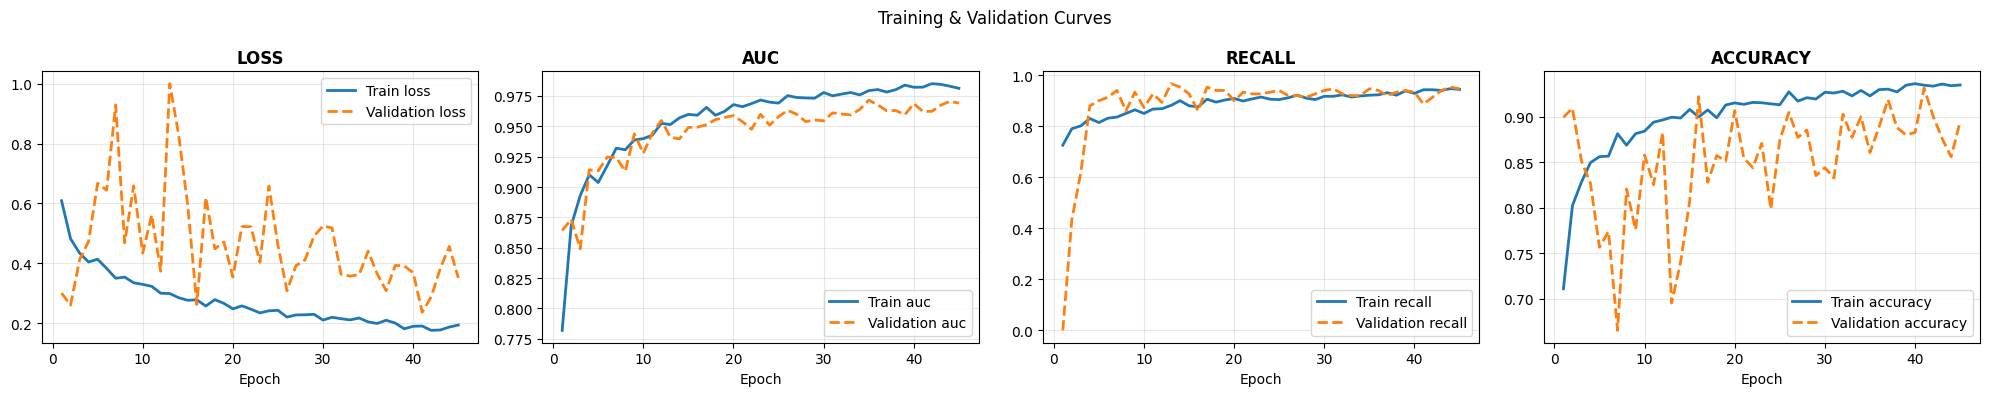
Early stopping due to overfit, noisy loss and accuracy


| Class | Precision | Recall | F1-Score | Support |
| --- | --- | --- | --- | --- |
| **normal** | 0.99 | 0.87 | 0.92 | 1350 |
| **spiderman** | 0.44 | 0.94 | 0.60 | 150 |
| --- | --- | --- | --- | --- |
| **accuracy** |  |  | 0.87 | 1500 |
| **macro avg** | 0.72 | 0.90 | 0.76 | 1500 |
| **weighted avg** | 0.94 | 0.87 | 0.89 | 1500 |

### Curves
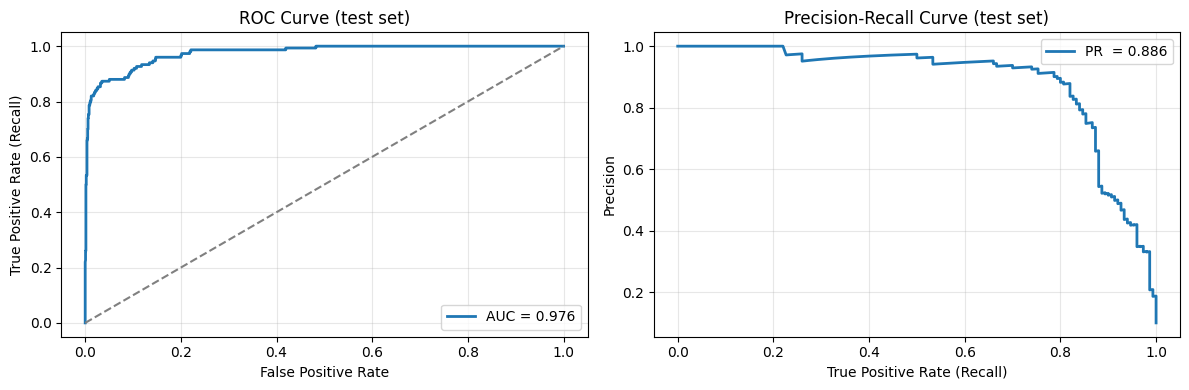

- **AUC**: 0.976
- **PR AUC**: 0.886



### Confusion matrix
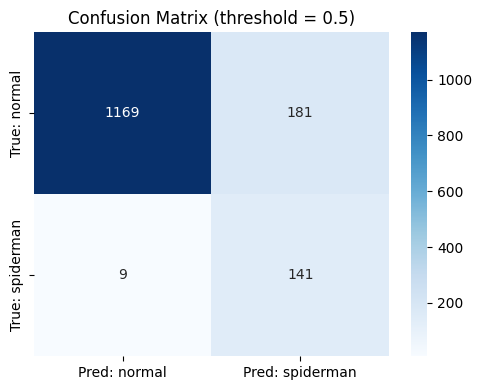
- True Negatives (correct normal) : 1169
- False Positives (normal→flagged): 181 -> recoverable error
- False Negatives (flagged→normal): 9 -> critical error
- True Positives (correct flagged): 141
### Threshold optimization
- Recall target: ≥ 0.95
- Chosen threshold: 0.4751
- Recall: 0.9533
- precision: 0.4074
- F1: 0.5709

> Precision doesn't look great!

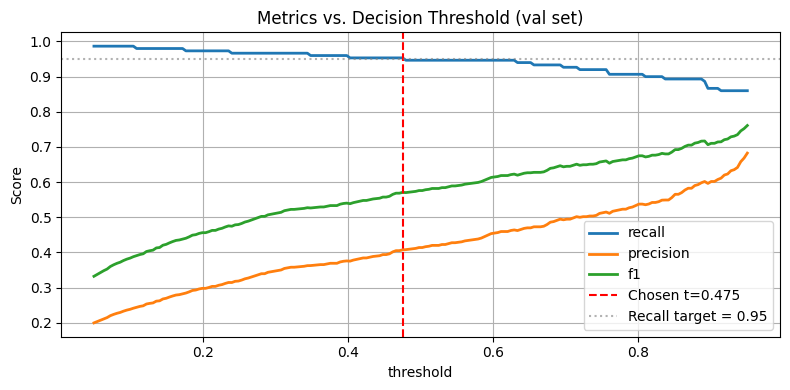

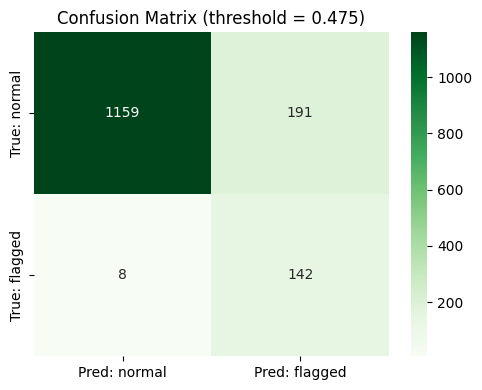

| Class | Precision | Recall | F1-Score | Support |
| --- | --- | --- | --- | --- |
| **normal** | 0.99 | 0.86 | 0.92 | 1350 |
| **flagged** | 0.43 | 0.95 | 0.59 | 150 |
| --- | --- | --- | --- | --- |
| **accuracy** |  |  | 0.87 | 1500 |
| **macro avg** | 0.71 | 0.90 | 0.75 | 1500 |
| **weighted avg** | 0.94 | 0.87 | 0.89 | 1500 |

Recall for the flagged spiderman class is now 95%, but we buy many false negatives and a worse precision, thats why the Precision-Recall Curve is important to us to look at.

### Examples of false labeled images on uncleaned train and val dataset:
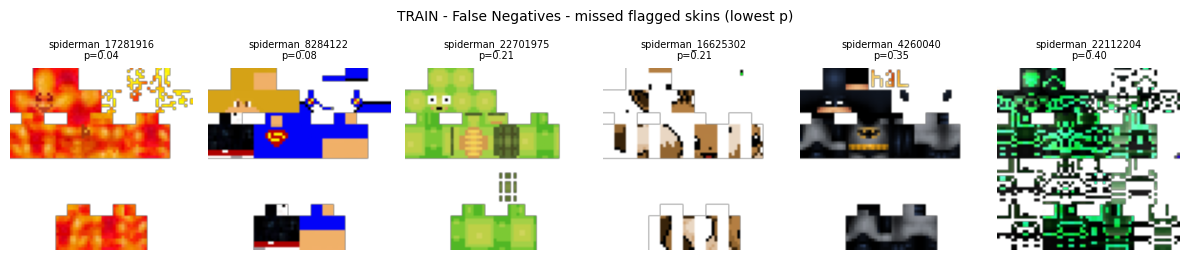
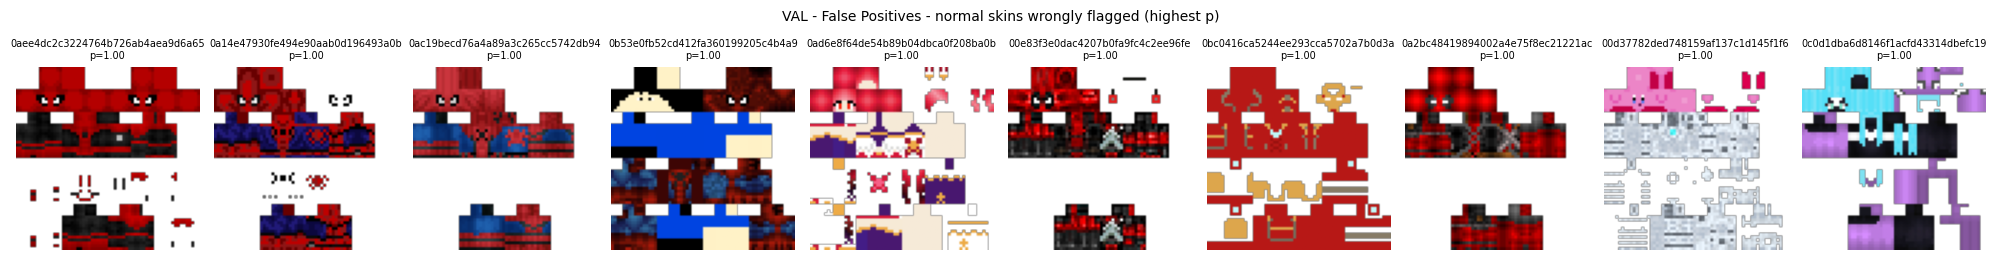

> So the model is trying to generalize even with false labeled data. How can we improve our model?
> Hypothesis: Cleaning/re-labeling the obvious false images predictions might show improvements..
> Also it thinks deadpool is spiderman
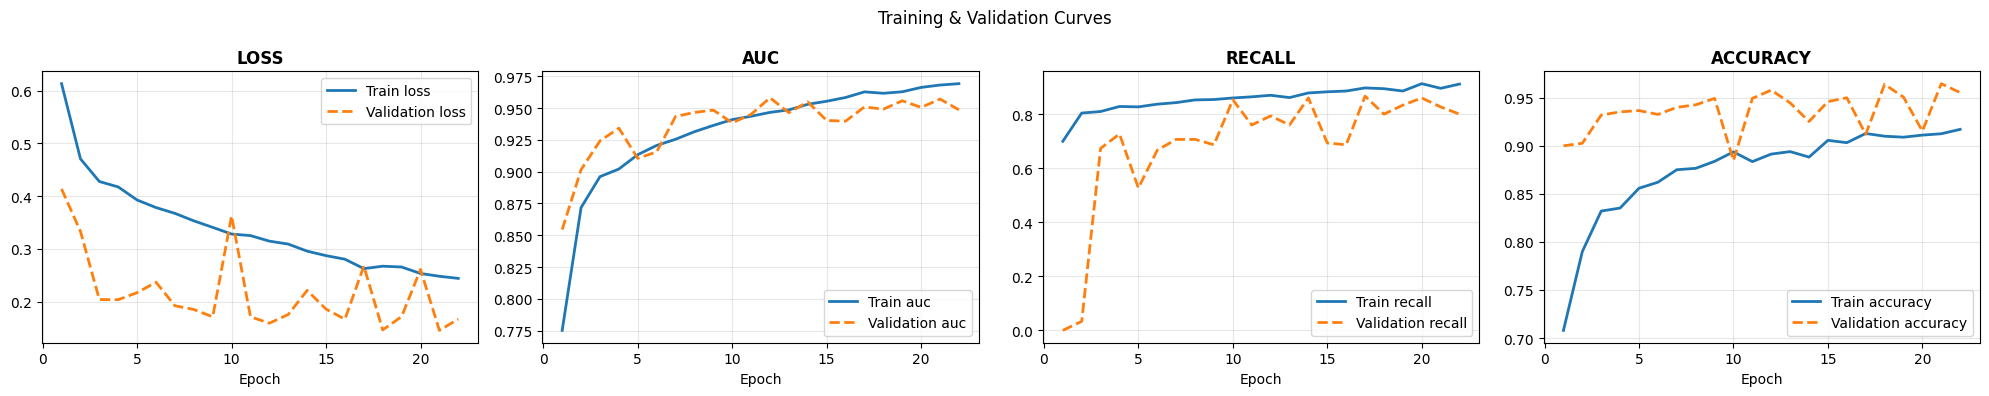
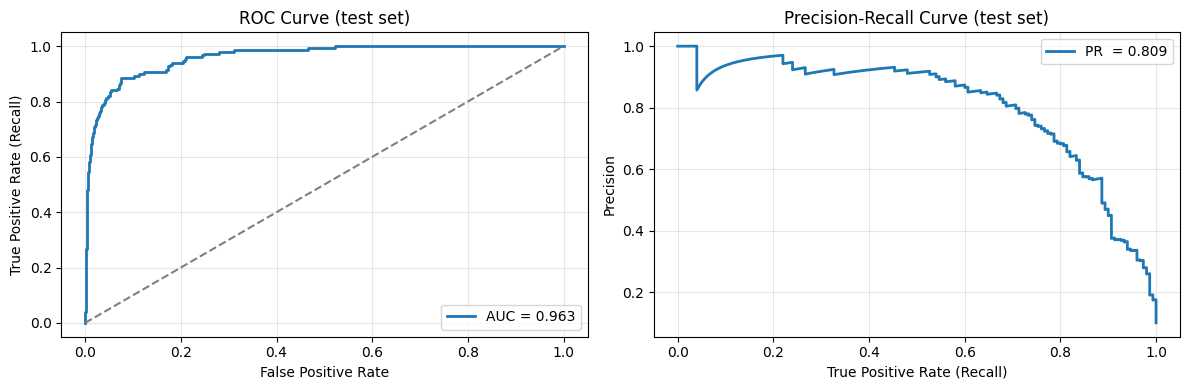
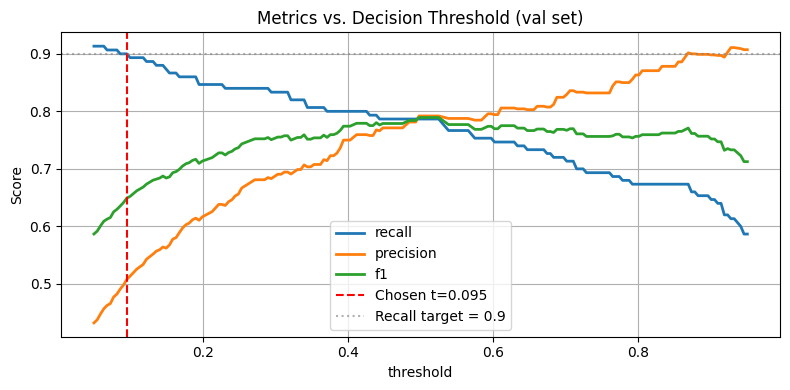
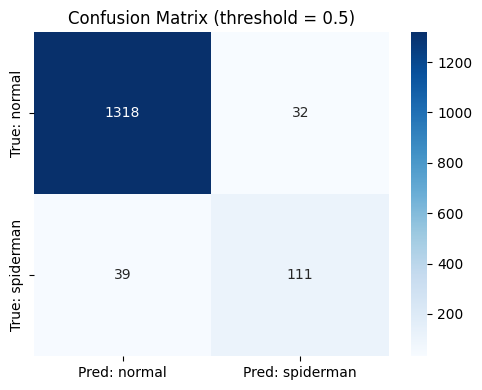
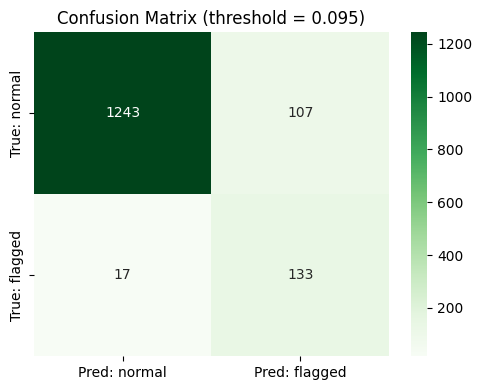
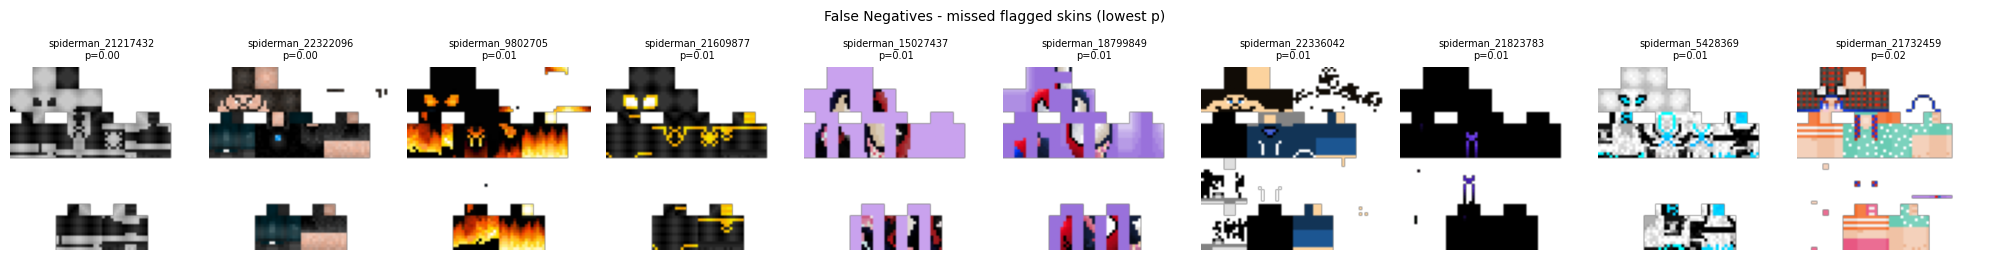
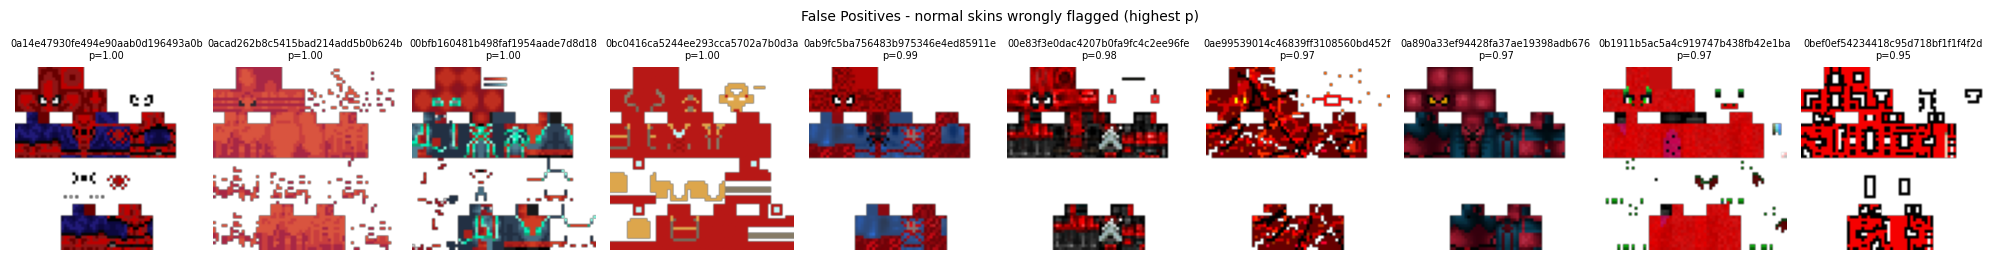
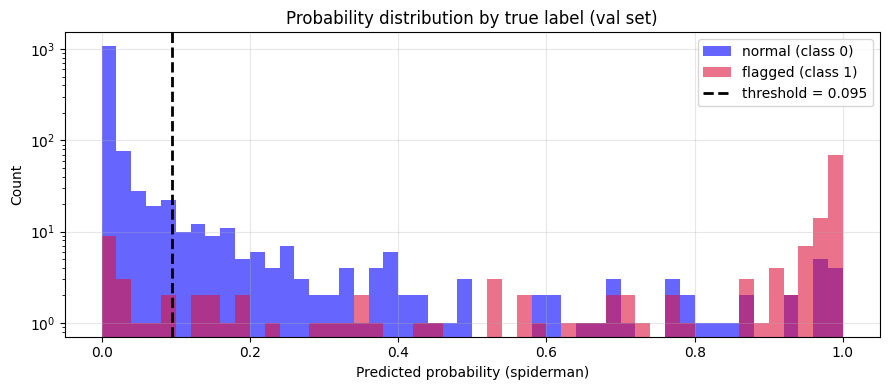

## 2. Full Notebook runs on modified dataset
> Overall less noisy training (less 'confusion' pobably due to better data) still not perfect due to many false positive normal skins (class weight)

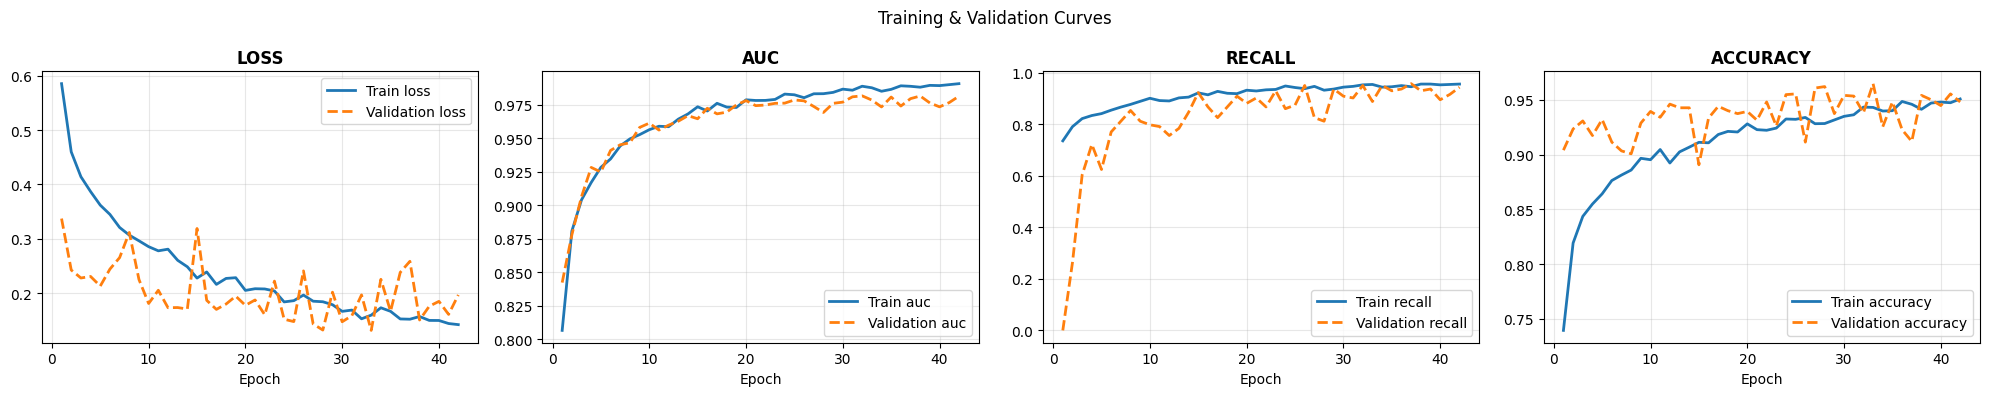

Spiderman Precision jumped from 0.44 to 0.63

| Class | Precision | Recall | F1-Score | Support |
| --- | --- | --- | --- | --- |
| **normal** | 0.99 | 0.94 | 0.97 | 1356 |
| **spiderman** | 0.63 | 0.93 | 0.75 | 144 |
| --- | --- | --- | --- | --- |
| **accuracy** |  |  | 0.94 | 1500 |
| **macro avg** | 0.81 | 0.94 | 0.86 | 1500 |
| **weighted avg** | 0.96 | 0.94 | 0.95 | 1500 |



### Curves
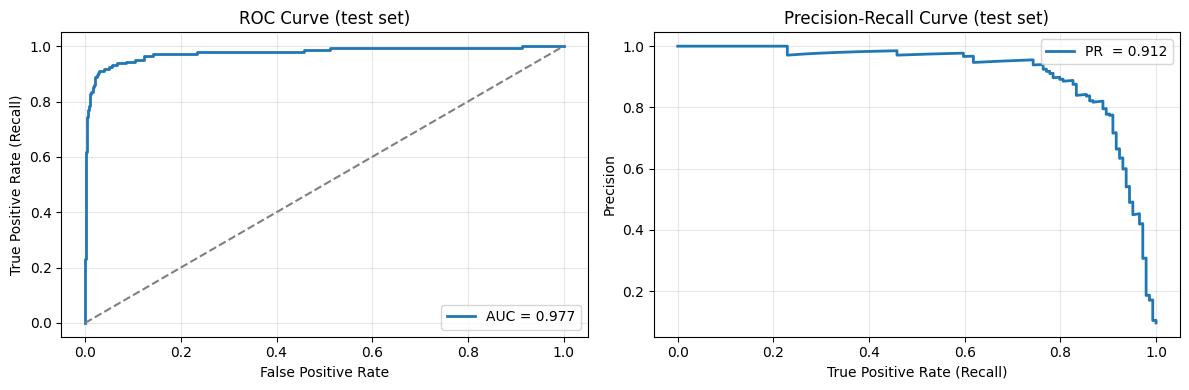
- **AUC**: 0.977
- **PR AUC**: 0.912 (increased from 0.886)
### Confusion Matrix

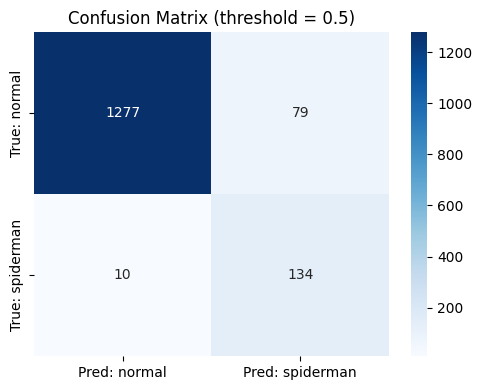

- True Negatives (correct normal) : 1277
- False Positives (normal→flagged): 79 -> recoverable error
- False Negatives (flagged→normal): 10 -> critical error
- True Positives (correct flagged): 134

Before
> - True Negatives (correct normal) : 1169
> - False Positives (normal→flagged): 181 -> recoverable error
> - False Negatives (flagged→normal): 9 -> critical error
> - True Positives (correct flagged): 141

Overall better predictions -> Accuracy jumped from 0.87 to 0.94

### Threshold Optimization

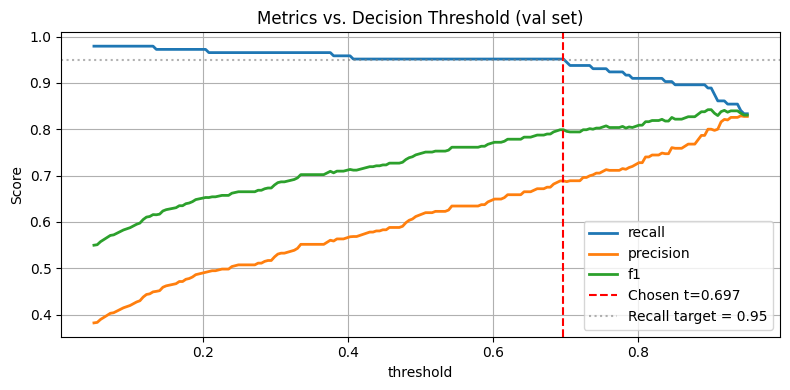
> Threshold can be at a higher level (0.6967) than before (0.47) because classes are better separable (recall at higher thresholds)

### Classification report on new threshold
| Class | Precision | Recall | F1-Score | Support |
| --- | --- | --- | --- | --- |
| **normal** | 0.99 | 0.96 | 0.97 | 1356 |
| **flagged** | 0.70 | 0.92 | 0.80 | 144 |
| --- | --- | --- | --- | --- |
| **accuracy** |  |  | 0.95 | 1500 |
| **macro avg** | 0.85 | 0.94 | 0.88 | 1500 |
| **weighted avg** | 0.96 | 0.95 | 0.96 | 1500 |

> --> precision now at 0.7 with similar high recall (0.92), accuracy increased too

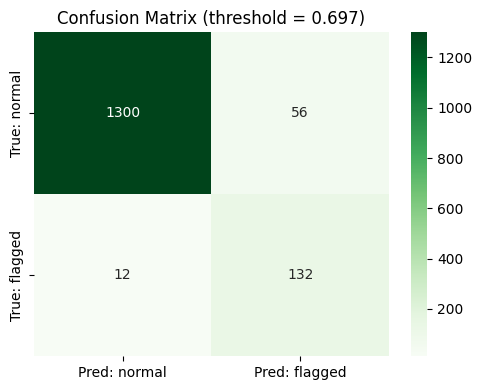

#### remaining misclassifications

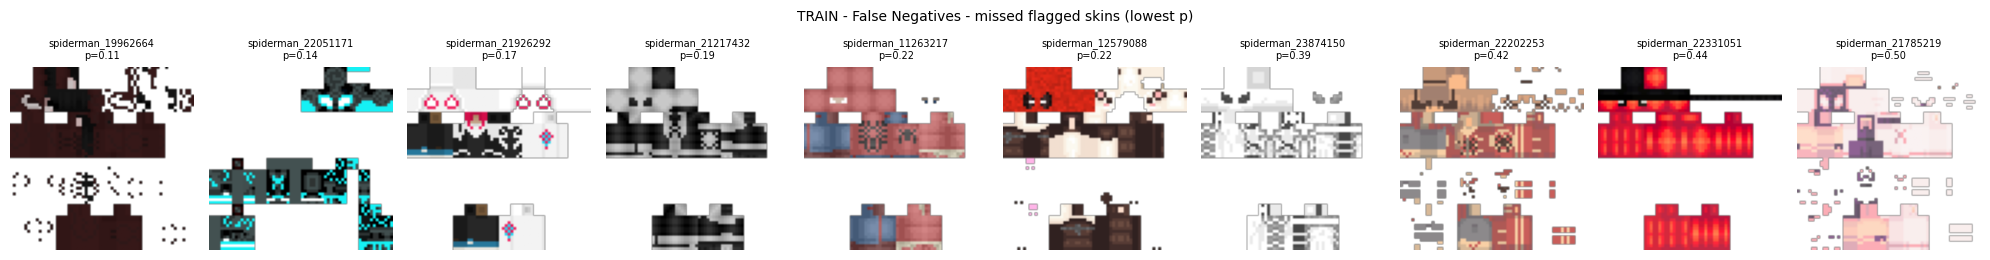
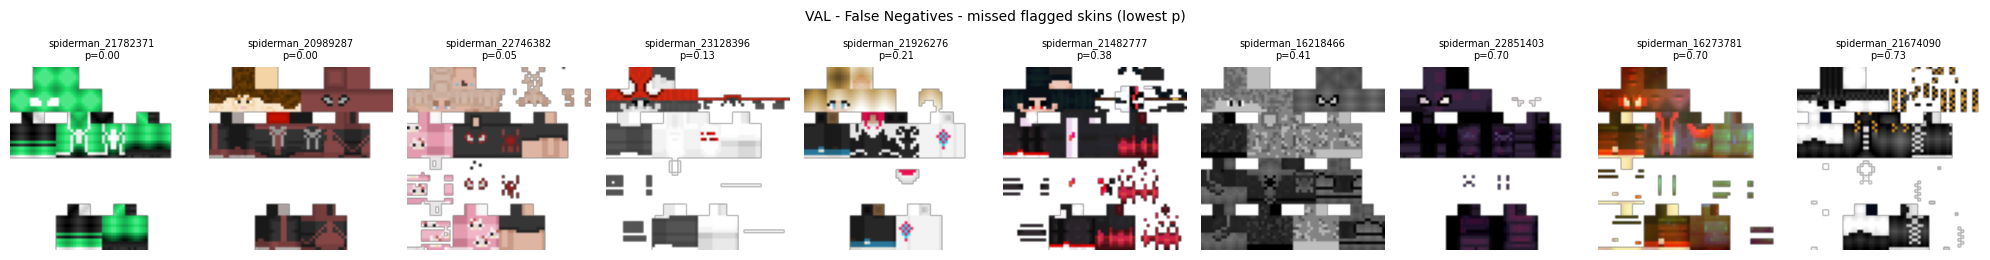
>
> Dataset is still not perfect as we can see. This type of 'active learning strategy' should be continued
>
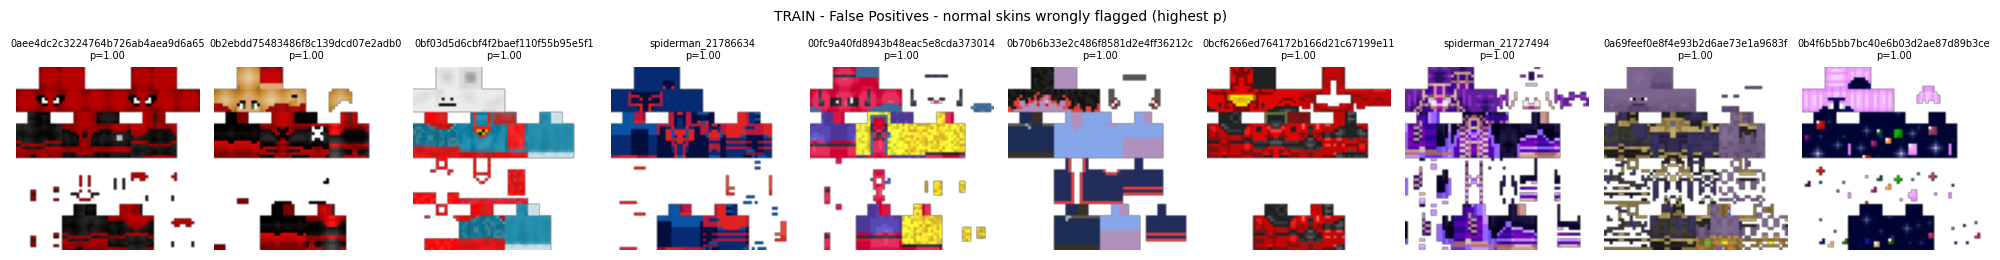
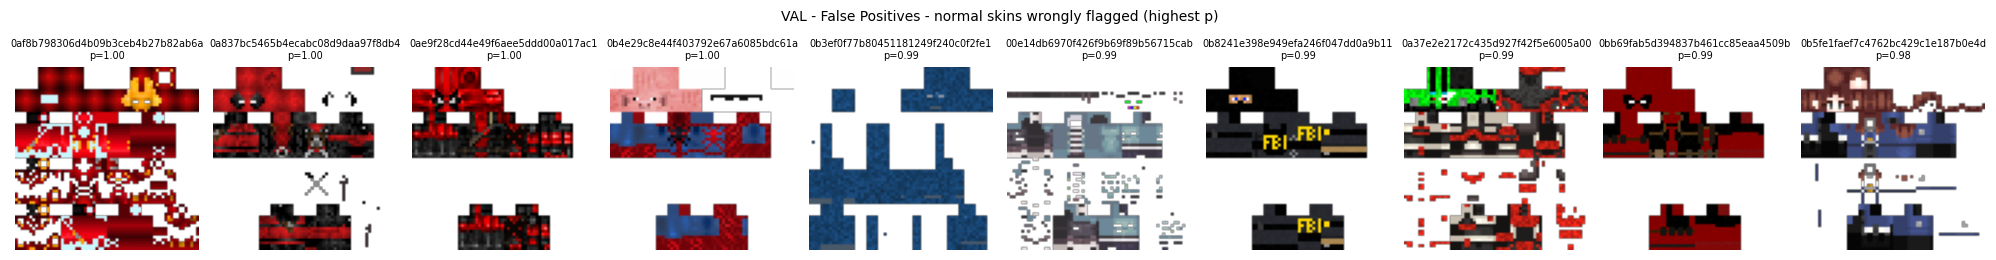


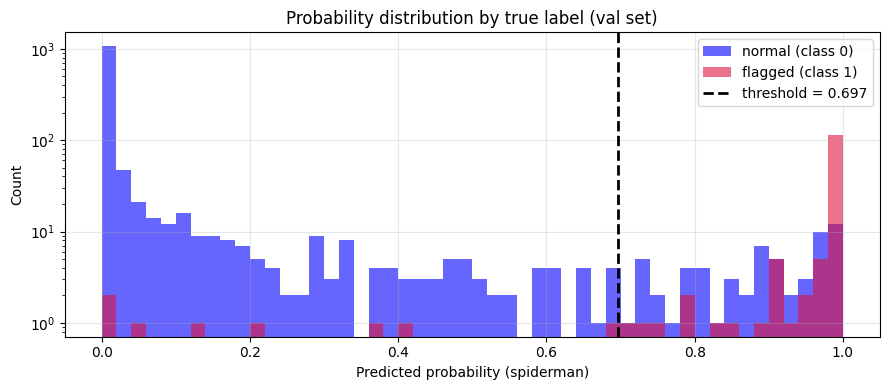
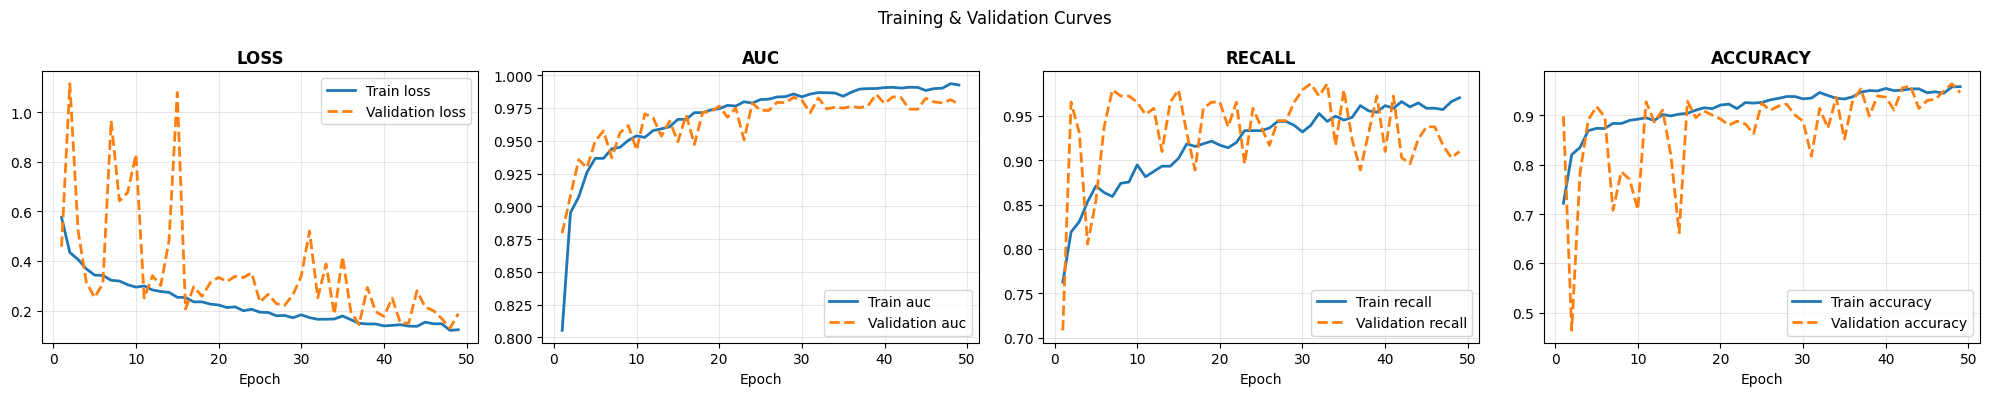
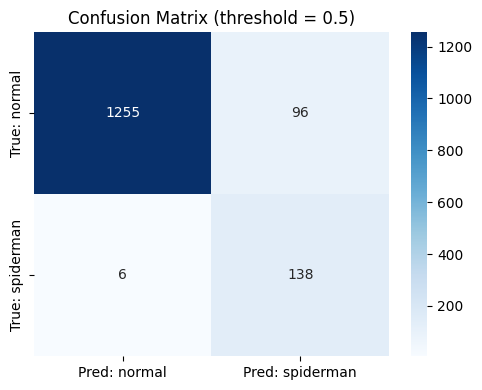
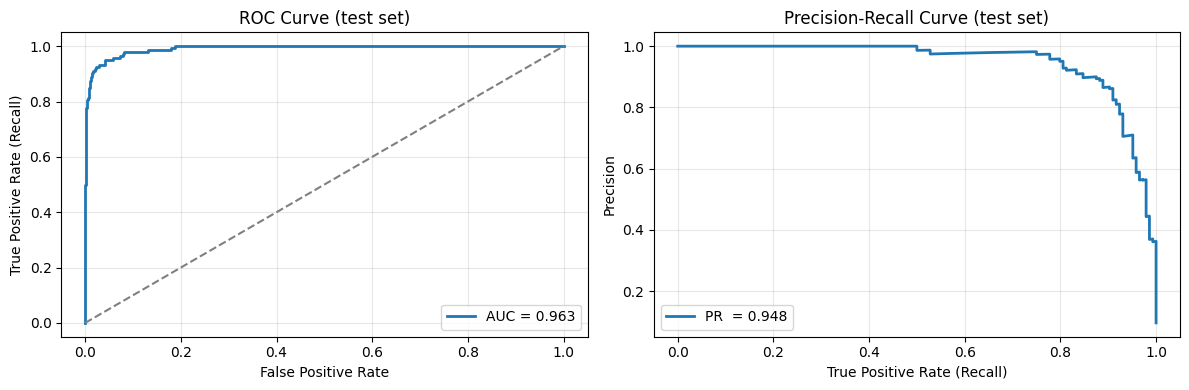
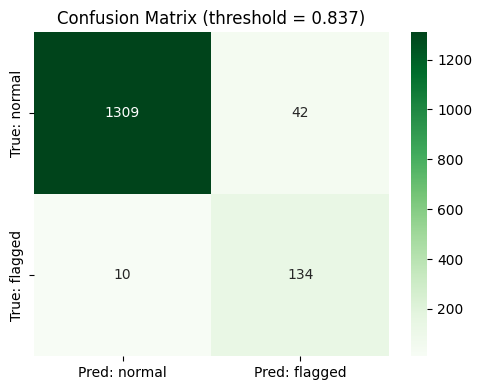
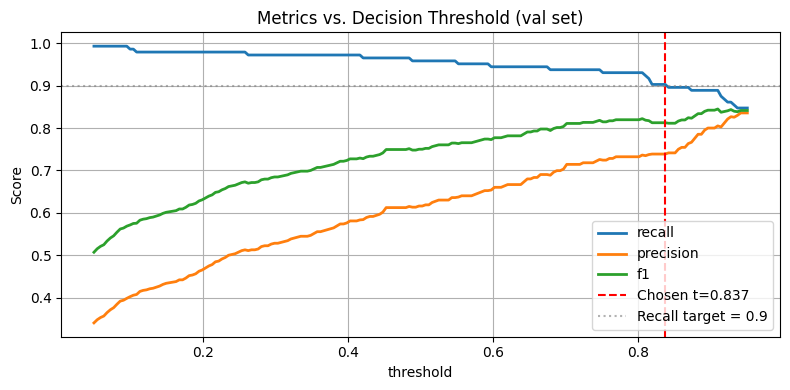

---
## Conclusion & Learnings

### What we built

A binary CNN classifier for Minecraft skin images (64×64 RGBA) that detects copyrighted/banned character skins with high recall.

### Key design decisions and why they matter

| Decision          | Impact                                                                                              |
|-------------------|-----------------------------------------------------------------------------------------------------|
| Class Weighting   | Imbalanced dataset with minority class (flagged) as recall target, prevent guessing the major class |
| Data Augmentation | more variety in training data                                                                       |
| CNN               | Standard choice for image data, MNIST notebook PoC was our inspiration for this bigger project      |
| Recall instead of accuracy | High accuracy is misleading, we want to risk false alarms over missing spiderman |
| PR AUC vs ROC AUC | ROC was always very high, probably because of the "normal" class. The Precision-Recall is better, because it shows the impact of recall and false alarms |


### Discussion: Data Quality vs. Test Leakage
- We relabeled the false predictions in the folders
- We improved the quality of the dataset

- Model trained on its own "labeled" data
- The test set is no longer completely independent

- Lesson learned: In the future, we should strictly separate the data cleaning process from modeling
- Keep test set locked for final evaluation

## Black Box
- Did the model learn red and blue colors or 'real' class-specific structures?